In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Sequence

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import efficient_su2
from dyn_esu2 import dynamic_esu2
from estimator import MyEstimator

from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

from itertools import product

import warnings
warnings.filterwarnings("ignore")

In [2]:
from hamlib_snippets import get_hdf5_keys, read_qiskit_hdf5
keys = get_hdf5_keys('heis.hdf5')

In [3]:
num_sites = [3, 10]
couplings = [0.5, 2]

hamiltonians = dict()
for n, h in product(num_sites, couplings) :
    hamiltonian = read_qiskit_hdf5('heis.hdf5', f'graph-1D-grid-nonpbc-qubitnodes_Lx-{n}_h-{h}')
    hamiltonians[(n, h)] = hamiltonian
    print(n, h, hamiltonian)

3 0.5 SparsePauliOp(['XXI', 'YYI', 'ZZI', 'IXX', 'IYY', 'IZZ', 'ZII', 'IZI', 'IIZ'],
              coeffs=[1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 0.5+0.j, 0.5+0.j,
 0.5+0.j])
3 2 SparsePauliOp(['XXI', 'YYI', 'ZZI', 'IXX', 'IYY', 'IZZ', 'ZII', 'IZI', 'IIZ'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 2.+0.j, 2.+0.j, 2.+0.j])
10 0.5 SparsePauliOp(['XXIIIIIIII', 'YYIIIIIIII', 'ZZIIIIIIII', 'IXXIIIIIII', 'IYYIIIIIII', 'IZZIIIIIII', 'IIXXIIIIII', 'IIYYIIIIII', 'IIZZIIIIII', 'IIIXXIIIII', 'IIIYYIIIII', 'IIIZZIIIII', 'IIIIXXIIII', 'IIIIYYIIII', 'IIIIZZIIII', 'IIIIIXXIII', 'IIIIIYYIII', 'IIIIIZZIII', 'IIIIIIXXII', 'IIIIIIYYII', 'IIIIIIZZII', 'IIIIIIIXXI', 'IIIIIIIYYI', 'IIIIIIIZZI', 'IIIIIIIIXX', 'IIIIIIIIYY', 'IIIIIIIIZZ', 'ZIIIIIIIII', 'IZIIIIIIII', 'IIZIIIIIII', 'IIIZIIIIII', 'IIIIZIIIII', 'IIIIIZIIII', 'IIIIIIZIII', 'IIIIIIIZII', 'IIIIIIIIZI', 'IIIIIIIIIZ'],
              coeffs=[1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.

In [4]:
n, h = 3, 0.5
hamiltonian = hamiltonians[(n, h)]
print(hamiltonian)

SparsePauliOp(['XXI', 'YYI', 'ZZI', 'IXX', 'IYY', 'IZZ', 'ZII', 'IZI', 'IIZ'],
              coeffs=[1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 0.5+0.j, 0.5+0.j,
 0.5+0.j])


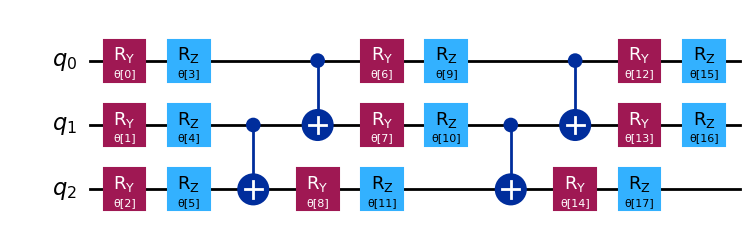

In [5]:
ansatz = efficient_su2(num_qubits=n, reps=2)
ansatz.draw("mpl", style="iqp")

In [6]:
opt_params = np.load(f'params/params_{n}_{h}.npy')
print(opt_params)

[ 2.50192485  6.78103616  4.15948528  3.95471108  0.98379362  0.85347157
 -0.37708709  6.32721583  3.84196396  4.40179715  0.99799012  6.53940704
  6.07499762  1.01750486  0.88148506  1.11368622  1.4593727   3.70964586]


In [7]:
service = QiskitRuntimeService()
backend_name = 'ibm_kingston'
backend = service.backend(backend_name)

qiskit_runtime_service.__init__:WARNING:2026-04-22 21:31:01,434: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (premium), the available account instances are: m5000-eu, m5000-us. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-22 21:31:01,435: Using instance: m5000-us, plan: premium


In [8]:
sampler = Sampler(backend)

In [9]:
my_estimator = MyEstimator('test_estimator', ansatz, opt_params, hamiltonian, sampler, service, backend)

In [10]:
my_estimator.commuting_groups

[SparsePauliOp(['XXI', 'IXX'],
               coeffs=[1.+0.j, 1.+0.j]),
 SparsePauliOp(['YYI', 'IYY'],
               coeffs=[1.+0.j, 1.+0.j]),
 SparsePauliOp(['ZZI', 'IZZ', 'IZI', 'ZII', 'IIZ'],
               coeffs=[1. +0.j, 1. +0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j])]

In [11]:
my_estimator.submit_sampler_jobs()

Sampler jobs already submitted. Result in jobs/test_estimator.json.


In [12]:
expval = my_estimator.evaluate_expectation_value()
print(expval)

-2.997802734375
